# Scheme B vs C: Performance Comparison

Runs both approaches on the **same** config and data:
- **Scheme B**: Regression (Huber loss) → scalar K estimate
- **Scheme C**: Classification (CrossEntropy) → K classes 0..Kmax

Compares: val MAE, accuracy (C only), and confusion-style diagnostics.

In [11]:
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

In [12]:
### Utilities

def deep_update(base: dict, updates: dict) -> dict:
    out = deepcopy(base)
    for k, v in updates.items():
        if isinstance(v, dict) and isinstance(out.get(k, None), dict):
            out[k] = deep_update(out[k], v)
        else:
            out[k] = deepcopy(v)
    return out

In [13]:
### Synthetic spectrum generator (from Scheme C – supports k_mode)

DEFAULT_GEN = dict(
    k_mode="poisson",
    p_zero=0.0,
    k_mean=3.0,
    k_tail_prob=0.50,
    k_tail_min=6,
    amp_lognorm_mu=0.0,
    amp_lognorm_sigma=1.0,
    sigma_min=0.1,
    sigma_max=10.0,
    blend_cluster_prob=0.0,
    cluster_width_range=(1.0, 30.0),
    noise_std_range=(0.02, 0.15),
    baseline_poly_prob=0.5,
    baseline_max_slope=0.02,
    baseline_max_quad=0.0002,
)

def _make_v_axis(cfg: dict) -> np.ndarray:
    vmin, vmax = cfg["vrange"]
    C = int(cfg["n_channels"])
    return np.linspace(vmin, vmax, C, dtype=np.float32)

def generate_spectrum(cfg: dict, rng: np.random.Generator, v_axis=None) -> dict:
    vmin, vmax = cfg["vrange"]
    C = int(cfg["n_channels"])
    Kmax = int(cfg["max_components"])
    min_components = int(cfg.get("min_components", 0))
    gen = deep_update(DEFAULT_GEN, cfg.get("gen", {}))
    k_tail_max = min(10, Kmax)
    v = v_axis if v_axis is not None else _make_v_axis(cfg)

    if rng.random() < gen["p_zero"]:
        k = 0
    else:
        if gen.get("k_mode", "poisson") == "uniform":
            k = int(rng.integers(0, Kmax + 1))
            if k > 0:
                k = max(k, min_components)
        else:
            if rng.random() < gen["k_tail_prob"]:
                k = int(rng.integers(gen["k_tail_min"], k_tail_max + 1))
            else:
                k = max(1, int(rng.poisson(gen["k_mean"])))
            k = max(k, min_components) if k > 0 else 0
    k = min(k, Kmax)

    A = np.zeros(Kmax, dtype=np.float32)
    mu = np.zeros(Kmax, dtype=np.float32)
    sig = np.ones(Kmax, dtype=np.float32)

    if k > 0:
        if rng.random() < gen["blend_cluster_prob"] and k >= 2:
            center = rng.uniform(vmin + 0.2*(vmax - vmin), vmax - 0.2*(vmax - vmin))
            cw = rng.uniform(*gen["cluster_width_range"])
            mus = center + rng.normal(0.0, cw, size=k)
            mus = np.clip(mus, vmin, vmax)
        else:
            mus = rng.uniform(vmin, vmax, size=k)
        sigs = rng.uniform(gen["sigma_min"], gen["sigma_max"], size=k)
        amps = rng.lognormal(mean=gen["amp_lognorm_mu"], sigma=gen["amp_lognorm_sigma"], size=k)
        amps = amps / (np.percentile(amps, 90) + 1e-6)
        order = np.argsort(mus)
        mus, sigs, amps = mus[order], sigs[order], amps[order]
        A[:k] = amps.astype(np.float32)
        mu[:k] = mus.astype(np.float32)
        sig[:k] = sigs.astype(np.float32)

    spec = np.zeros(C, dtype=np.float32)
    for i in range(k):
        dv = (v - mu[i]) / (sig[i] + 1e-6)
        spec += A[i] * np.exp(-0.5 * dv * dv).astype(np.float32)
    spec_clean = spec.copy()

    if rng.random() < gen["baseline_poly_prob"]:
        x = np.linspace(-1, 1, C, dtype=np.float32)
        slope = rng.uniform(-gen["baseline_max_slope"], gen["baseline_max_slope"])
        quad = rng.uniform(-gen["baseline_max_quad"], gen["baseline_max_quad"])
        spec += (slope * x + quad * (x**2)).astype(np.float32)

    noise_std = float(rng.uniform(*gen["noise_std_range"]))
    spec += rng.normal(0.0, noise_std, size=C).astype(np.float32)

    return dict(spec=spec, spec_clean=spec_clean, k=k, noise_std=np.array([noise_std], dtype=np.float32), v_axis=v)

In [14]:
### Dataset + loaders

class SyntheticSpectraDataset(Dataset):
    def __init__(self, cfg: dict, n_samples: int, base_seed: int = 0):
        self.cfg = cfg
        self.v_axis = _make_v_axis(cfg)
        self.n_samples = int(n_samples)
        self.base_seed = int(base_seed)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx: int):
        rng = np.random.default_rng(self.base_seed + int(idx))
        ex = generate_spectrum(self.cfg, rng=rng, v_axis=self.v_axis)
        K_true = np.array([ex["k"]], dtype=np.int64)
        return {
            "spec": torch.from_numpy(ex["spec"]).float(),
            "spec_clean": torch.from_numpy(ex["spec_clean"]).float(),
            "K_true": torch.from_numpy(K_true).long(),
        }

BASE_CFG = dict(
    n_channels=256,
    min_components=0,
    max_components=10,
    vrange=(-200.0, 200.0),
    gen=deepcopy(DEFAULT_GEN),
)

def make_loaders(cfg: dict, *, n_train=50_000, n_val=5_000, bs_train=128, bs_val=256):
    train_ds = SyntheticSpectraDataset(cfg, n_samples=n_train, base_seed=0)
    val_ds = SyntheticSpectraDataset(cfg, n_samples=n_val, base_seed=10_000_000)
    train_loader = DataLoader(train_ds, batch_size=bs_train, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_ds, batch_size=bs_val, shuffle=False, num_workers=0, pin_memory=False)
    return train_loader, val_loader

In [15]:
### Models (from Scheme B and Scheme C)

class CountNet1D(nn.Module):
    """Scheme B: regression head → scalar K."""
    def __init__(self, width=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, width, 9, padding=4),
            nn.ReLU(),
            nn.Conv1d(width, width, 9, padding=4),
            nn.ReLU(),
            nn.Conv1d(width, width, 9, padding=4),
            nn.ReLU(),
        )
        self.head = nn.Linear(width, 1)

    def forward(self, x):
        h = self.conv(x.unsqueeze(1))
        h = h.mean(dim=-1)
        return self.head(h).squeeze(-1)

class CountNet1D_Classify(nn.Module):
    """Scheme C: classification head → logits for 0..Kmax."""
    def __init__(self, Kmax: int, width: int = 64):
        super().__init__()
        self.Kmax = int(Kmax)
        self.conv = nn.Sequential(
            nn.Conv1d(1, width, 9, padding=4),
            nn.ReLU(),
            nn.Conv1d(width, width, 9, padding=4),
            nn.ReLU(),
            nn.Conv1d(width, width, 9, padding=4),
            nn.ReLU(),
        )
        self.head = nn.Linear(width, self.Kmax + 1)

    def forward(self, x):
        h = self.conv(x.unsqueeze(1))
        h = h.mean(dim=-1)
        return self.head(h)

In [16]:
### Training loops

def _norm(x):
    x = x - x.mean(dim=1, keepdim=True)
    return x / (x.std(dim=1, keepdim=True) + 1e-6)

def train_scheme_b(model, train_loader, val_loader, *, device="cpu", lr=1e-3, epochs=3, log_every=200, Kmax=10):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.SmoothL1Loss(beta=1.0)
    n_steps = len(train_loader)
    print(f"[B] Starting: {epochs} epochs, {n_steps} steps/epoch, log every {log_every}")
    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        print(f"[B] Epoch {ep}/{epochs}")
        for step, batch in enumerate(train_loader, start=1):
            x = _norm(batch["spec"].to(device))
            K = batch["K_true"].to(device).float().squeeze(-1)
            K_hat = model(x)
            loss = loss_fn(K_hat, K)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            running += loss.item()
            if step % log_every == 0:
                print(f"  [B]   step {step}/{n_steps}  train_loss {running/log_every:.4f}")
                running = 0.0
        model.eval()
        mae, n = 0.0, 0
        with torch.no_grad():
            for batch in val_loader:
                x = _norm(batch["spec"].to(device))
                K = batch["K_true"].to(device).long().squeeze(-1)
                K_hat = model(x)
                K_pred = torch.clamp(torch.round(K_hat), 0, Kmax).long()
                mae += (K_pred - K).abs().sum().item()
                n += x.size(0)
        print(f"  [B]   val_K_MAE {mae/n:.3f}")
    return model

def train_scheme_c(model, train_loader, val_loader, *, device="cpu", lr=1e-3, epochs=3, log_every=200):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    n_steps = len(train_loader)
    print(f"[C] Starting: {epochs} epochs, {n_steps} steps/epoch, log every {log_every}")
    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0
        print(f"[C] Epoch {ep}/{epochs}")
        for step, batch in enumerate(train_loader, start=1):
            x = _norm(batch["spec"].to(device))
            K = batch["K_true"].to(device).long().squeeze(-1)
            logits = model(x)
            loss = loss_fn(logits, K)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            running += loss.item()
            if step % log_every == 0:
                print(f"  [C]   step {step}/{n_steps}  train_loss {running/log_every:.4f}")
                running = 0.0
        model.eval()
        n, n_correct, mae_argmax, mae_expected = 0, 0, 0.0, 0.0
        with torch.no_grad():
            for batch in val_loader:
                x = _norm(batch["spec"].to(device))
                K = batch["K_true"].to(device).long().squeeze(-1)
                logits = model(x)
                Kp = torch.argmax(logits, dim=1)
                probs = torch.softmax(logits, dim=1)
                ks = torch.arange(probs.shape[1], device=device).float()
                Ke = (probs * ks[None, :]).sum(dim=1)
                n += x.size(0)
                n_correct += (Kp == K).sum().item()
                mae_argmax += (Kp - K).abs().sum().item()
                mae_expected += (Ke - K.float()).abs().sum().item()
        acc = n_correct / max(1, n)
        print(f"  [C]   val_acc {acc:.3f}  val_K_MAE(argmax) {mae_argmax/n:.3f}  val_K_MAE(E[K]) {mae_expected/n:.3f}")
    return model

In [17]:
### Run both schemes on same data

cfg = deep_update(BASE_CFG, {})
Kmax = int(cfg["max_components"])

train_loader, val_loader = make_loaders(cfg, n_train=50_000, n_val=5_000, bs_train=128, bs_val=256)
device = "cuda" if torch.cuda.is_available() else "cpu"

print("=== Scheme B (regression) ===")
model_b = CountNet1D(width=64)
model_b = train_scheme_b(model_b, train_loader, val_loader, device=device, lr=1e-3, epochs=3, log_every=200, Kmax=Kmax)

print("\n=== Scheme C (classification) ===")
model_c = CountNet1D_Classify(Kmax=Kmax, width=64)
model_c = train_scheme_c(model_c, train_loader, val_loader, device=device, lr=1e-3, epochs=3, log_every=200)

=== Scheme B (regression) ===
  [B] epoch 1 step 200 train_loss 1.6267
  [B] epoch 1 val_K_MAE 1.646
  [B] epoch 2 step 200 train_loss 1.1699
  [B] epoch 2 val_K_MAE 1.375
  [B] epoch 3 step 200 train_loss 0.9941
  [B] epoch 3 val_K_MAE 1.367

=== Scheme C (classification) ===
  [C] epoch 1 step 200 train_loss 2.0205
  [C] epoch 1 val_acc 0.280  val_K_MAE(argmax) 1.581  val_K_MAE(E[K]) 1.484
  [C] epoch 2 step 200 train_loss 1.8110
  [C] epoch 2 val_acc 0.308  val_K_MAE(argmax) 1.430  val_K_MAE(E[K]) 1.379
  [C] epoch 3 step 200 train_loss 1.7548
  [C] epoch 3 val_acc 0.276  val_K_MAE(argmax) 1.502  val_K_MAE(E[K]) 1.549


In [18]:
### Collect predictions for comparison

@torch.no_grad()
def collect_predictions(model_b, model_c, loader, device, Kmax, max_batches=100):
    model_b.eval()
    model_c.eval()
    y_true, y_b, y_c_argmax, y_c_exp = [], [], [], []
    for bi, batch in enumerate(loader):
        if bi >= max_batches:
            break
        x = _norm(batch["spec"].to(device))
        K = batch["K_true"].to(device).long().squeeze(-1)

        K_b = model_b(x)
        K_b = torch.clamp(torch.round(K_b), 0, Kmax).long()

        logits = model_c(x)
        K_c = torch.argmax(logits, dim=1)
        probs = torch.softmax(logits, dim=1)
        ks = torch.arange(Kmax + 1, device=device).float()
        K_c_exp = (probs * ks[None, :]).sum(dim=1)

        y_true.append(K.cpu().numpy())
        y_b.append(K_b.cpu().numpy())
        y_c_argmax.append(K_c.cpu().numpy())
        y_c_exp.append(K_c_exp.cpu().numpy())

    return (
        np.concatenate(y_true),
        np.concatenate(y_b),
        np.concatenate(y_c_argmax),
        np.concatenate(y_c_exp),
    )

y_true, y_b, y_c_argmax, y_c_exp = collect_predictions(model_b, model_c, val_loader, device, Kmax)

In [19]:
### Summary metrics

mae_b = np.abs(y_b - y_true).mean()
mae_c_argmax = np.abs(y_c_argmax - y_true).mean()
mae_c_exp = np.abs(y_c_exp - y_true).mean()
acc_c = (y_c_argmax == y_true).mean()

print("=== Performance Summary (same val set) ===")
print(f"Scheme B (regression, rounded):  MAE = {mae_b:.3f}")
print(f"Scheme C (argmax):              MAE = {mae_c_argmax:.3f}  Accuracy = {acc_c:.3f}")
print(f"Scheme C (E[K] rounded):        MAE = {mae_c_exp:.3f}")

=== Performance Summary (same val set) ===
Scheme B (regression, rounded):  MAE = 1.367
Scheme C (argmax):              MAE = 1.502  Accuracy = 0.276
Scheme C (E[K] rounded):        MAE = 1.549


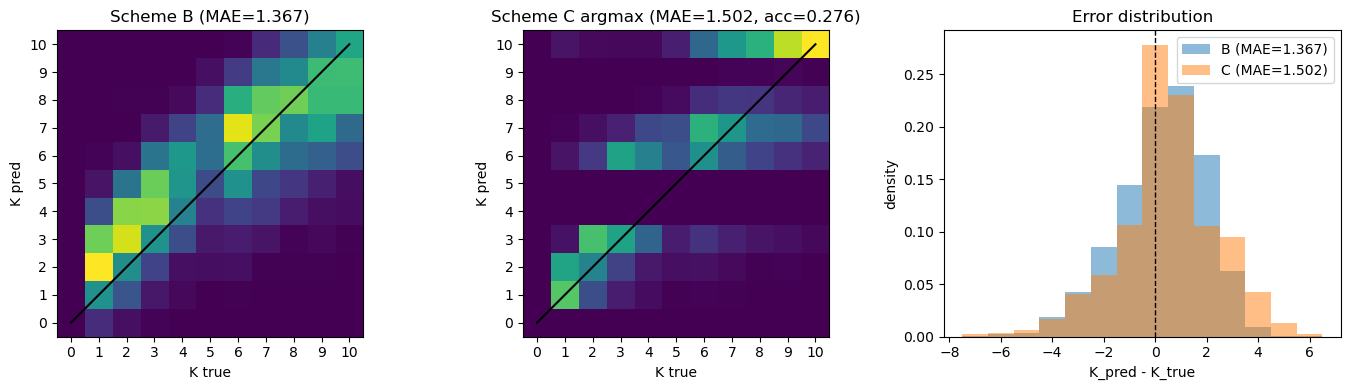

In [20]:
### Comparison plots

edges = np.arange(-0.5, Kmax + 1.5, 1.0)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

### B: true vs pred
H_b, _, _ = np.histogram2d(y_true, y_b, bins=[edges, edges])
axes[0].imshow(H_b.T, origin="lower", aspect="equal", extent=[edges[0], edges[-1], edges[0], edges[-1]])
axes[0].plot([0, Kmax], [0, Kmax], "k-", lw=1.5)
axes[0].set_xlabel("K true")
axes[0].set_ylabel("K pred")
axes[0].set_title(f"Scheme B (MAE={mae_b:.3f})")
axes[0].set_xticks(np.arange(0, Kmax + 1))
axes[0].set_yticks(np.arange(0, Kmax + 1))

### C argmax: true vs pred
H_c, _, _ = np.histogram2d(y_true, y_c_argmax, bins=[edges, edges])
axes[1].imshow(H_c.T, origin="lower", aspect="equal", extent=[edges[0], edges[-1], edges[0], edges[-1]])
axes[1].plot([0, Kmax], [0, Kmax], "k-", lw=1.5)
axes[1].set_xlabel("K true")
axes[1].set_ylabel("K pred")
axes[1].set_title(f"Scheme C argmax (MAE={mae_c_argmax:.3f}, acc={acc_c:.3f})")
axes[1].set_xticks(np.arange(0, Kmax + 1))
axes[1].set_yticks(np.arange(0, Kmax + 1))

### Error histograms
err_b = y_b - y_true
err_c = y_c_argmax - y_true
bins = np.arange(err_b.min() - 0.5, err_b.max() + 1.5, 1)
axes[2].hist(err_b, bins=bins, alpha=0.5, label=f"B (MAE={mae_b:.3f})", color="C0", density=True)
axes[2].hist(err_c, bins=bins, alpha=0.5, label=f"C (MAE={mae_c_argmax:.3f})", color="C1", density=True)
axes[2].axvline(0, color="k", ls="--", lw=1)
axes[2].set_xlabel("K_pred - K_true")
axes[2].set_ylabel("density")
axes[2].set_title("Error distribution")
axes[2].legend()

plt.tight_layout()
plt.show()